# 질문 답변

## 리뷰 기반 QA 시스템 구축하기

### 데이터셋

In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

In [70]:
!pip install --force-reinstall farm-haystack==1.25.0
!pip install --force-reinstall transformers==4.37.2 datasets==2.14.7 huggingface_hub==0.25.0 peft==0.10.0 pandas==2.2.2

  Using cached farm_haystack-1.25.0-py3-none-any.whl.metadata (27 kB)
  Using cached boilerpy3-1.0.7-py3-none-any.whl.metadata (5.8 kB)
  Using cached Events-0.5-py3-none-any.whl.metadata (3.9 kB)
  Using cached lazy_imports-0.3.1-py3-none-any.whl.metadata (10 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached posthog-7.20.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached prompthub_py-4.0.0-py3-none-any.whl.metadata (2.2 kB)
  Using cached pydantic-1.10.26-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (155 kB)
  Using cached quantulum3-0.10.0-py3-none-any.whl.metadata (17 kB)
  Using cached rank_bm25-0.2.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached requests_cache-0.9.8-py3-none-any.whl.metadata (8.7 kB)
  Using cached sseclient_py-1.9.0-py3-none-any.whl.m

In [5]:
!pip install --upgrade pip setuptools

  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.5 MB/s eta 0:00:00
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 81.0.0
    Uninstalling setuptools-81.0.0:
      Successfully uninstalled setuptools-81.0.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.12.1 requires setuptools<82, but you have setuptools 82.0.1 which is incompatible.
thinc 8.3.13 requires pydantic<3.0.0,>=2.0.0, but you have pydantic 1.10.26 which is incompatible.
torchvision 0.26.0+cu128 requires torch==2.11.0, but you ha

In [1]:
!pip install seqeval --no-cache-dir --no-build-isolation

  Preparing metadata (pyproject.toml) ... done
Discarding https://files.pythonhosted.org/packages/9d/2d/233c79d5b4e5ab1dbf111242299153f3caddddbb691219f363ad55ce783d/seqeval-1.2.2.tar.gz (from https://pypi.org/simple/seqeval/): Requested seqeval from https://files.pythonhosted.org/packages/9d/2d/233c79d5b4e5ab1dbf111242299153f3caddddbb691219f363ad55ce783d/seqeval-1.2.2.tar.gz has inconsistent version: expected '1.2.2', but metadata has '0.0.0'
  Preparing metadata (pyproject.toml) ... done
Discarding https://files.pythonhosted.org/packages/c4/47/f85f522f1f2532ca650474088e4024a9f52d524379bff058eaadf53cb663/seqeval-1.2.1.tar.gz (from https://pypi.org/simple/seqeval/): Requested seqeval from https://files.pythonhosted.org/packages/c4/47/f85f522f1f2532ca650474088e4024a9f52d524379bff058eaadf53cb663/seqeval-1.2.1.tar.gz has inconsistent version: expected '1.2.1', but metadata has '0.0.0'
  Preparing metadata (pyproject.toml) ... done
Discarding https://files.pythonhosted.org/packages/be/cd/d4

In [31]:
!pip install farm-haystack[metrics] farm-haystack[inference] farm-haystack[elasticsearch]

INFO: pip is looking at multiple versions of sentence-transformers to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of sentence-transformers to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
  Using cached pyarrow-21.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.3 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
Using cached packaging-25.0-py3-none-any.whl (66 kB)
Using cached pyarrow-21.0.0-cp312-cp312-manylinux_2_28_x86_64.whl (42.8 MB)
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 24.0.0
    Uninstalling pyarrow-24.0.0:
      Successfully uninstalled pyarrow-24.0

In [2]:
from datasets import get_dataset_config_names

domains = get_dataset_config_names("subjqa")
domains

['books', 'electronics', 'grocery', 'movies', 'restaurants', 'tripadvisor']

##### electornics 서브셋 다운

In [3]:
from datasets import load_dataset

subjqa = load_dataset("subjqa", name="electronics")

##### 답변 확인

In [4]:
print(subjqa["train"]["answers"][1])

{'text': ['Bass is weak as expected', 'Bass is weak as expected, even with EQ adjusted up'], 'answer_start': [1302, 1302], 'answer_subj_level': [1, 1], 'ans_subj_score': [0.5083333253860474, 0.5083333253860474], 'is_ans_subjective': [True, True]}


##### 중첩된 열을 펼치고 DataFrame으로 변환

In [5]:
import pandas as pd

dfs = {split: dset.to_pandas() for split, dset in subjqa.flatten().items()}

for split, df in dfs.items():
    print(f"{split}에 있는 질문 개수: {df['id'].nunique()}")

train에 있는 질문 개수: 1295
test에 있는 질문 개수: 358
validation에 있는 질문 개수: 255


##### 훈련 샘플 확인

In [6]:
qa_cols = ["title", "question", "answers.text",
           "answers.answer_start", "context"]
sample_df = dfs["train"][qa_cols].sample(2, random_state=7)
sample_df

,title,question,answers.text,answers.answer_start,context
791,B005DKZTMG,Does the keyboard lightweight?,[this keyboard is compact],[215],I really like this keyboard. I give it 4 star...
1159,B00AAIPT76,How is the battery?,[],[],I bought this after the first spare gopro batt...


##### 답변 텍스트 추출

In [7]:
start_idx = sample_df["answers.answer_start"].iloc[0][0]
end_idx = start_idx + len(sample_df["answers.text"].iloc[0][0])
sample_df["context"].iloc[0][start_idx:end_idx]

'this keyboard is compact'

##### 흔한 단어로 질문 개수 카운트

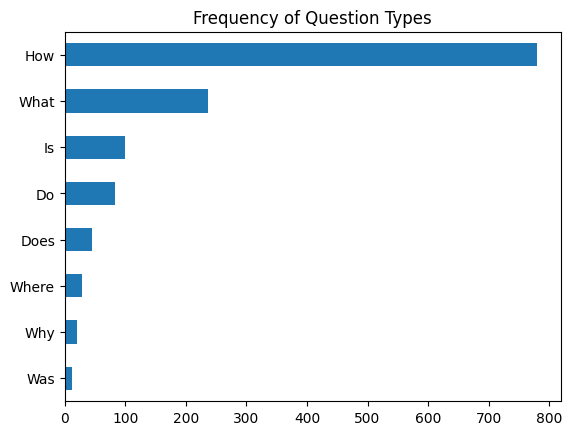

In [8]:
import matplotlib.pyplot as plt

counts = {}
question_types = ["What", "How", "Is", "Does", "Do", "Was", "Where", "Why"]

for q in question_types:
    counts[q] = dfs["train"]["question"].str.startswith(q).value_counts()[True]

pd.Series(counts).sort_values().plot.barh()
plt.title("Frequency of Question Types")
plt.show()

##### 샘플 더 확인하기

In [9]:
for question_type in ["How", "What", "Is"]:
    for question in (
        dfs["train"][dfs["train"].question.str.startswith(question_type)].sample(n=3, random_state=42)['question']):
        print(question)

How is the camera?
How do you like the control?
How fast is the charger?
What is direction?
What is the quality of the construction of the bag?
What is your impression of the product?
Is this how zoom works?
Is sound clear?
Is it a wireless keyboard?


### 텍스트에서 답 추출

#### 범위 분류

#### QA를 위한 텍스트 토큰화

##### 모델 체크포인트 로드

In [10]:
from transformers import AutoTokenizer

model_ckpt = "deepset/minilm-uncased-squad2"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


##### 질문, 문맥을 토크나이저에 전달

In [11]:
question = "How much music can this hold?"
context = """An MP3 is about 1MB/minute, so about 6000 hours depending on file size."""
inputs = tokenizer(question, context, return_tensors="pt")

##### input_ids 텐서 디코딩

In [12]:
print(tokenizer.decode(inputs["input_ids"][0]))

[CLS] how much music can this hold? [SEP] an mp3 is about 1mb / minute, so about 6000 hours depending on file size. [SEP]


##### QA 헤드와 함께 모델 객체를 초기화, 입력을 정방향 패스에 통과

In [13]:
import torch
from transformers import AutoModelForQuestionAnswering

model = AutoModelForQuestionAnswering.from_pretrained(model_ckpt)
with torch.no_grad():
    outputs = model(**inputs)
print(outputs)

Some weights of the model checkpoint at deepset/minilm-uncased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


QuestionAnsweringModelOutput(loss=None, start_logits=tensor([[-1.1224, -4.7834, -5.3935, -5.2447, -5.2899, -5.4980, -4.9885, -6.1783,
         -1.1224,  0.3651, -0.0807, -1.5551,  3.9556,  4.9206, -2.7833, -3.7461,
         -1.7211, -4.6096, -1.3769,  4.0256,  4.9715, -0.2477, -3.0354, -4.8180,
         -2.2386, -3.4867, -3.5462, -1.1224]]), end_logits=tensor([[-1.0707, -5.4840, -5.0304, -5.1770, -5.4496, -5.5120, -5.2013, -4.6178,
         -1.0707, -3.7223, -0.7583, -3.6969, -2.9205, -1.7346,  0.3122, -2.8688,
          4.8807,  0.2692, -3.1317, -3.2404,  0.8239,  5.6645, -0.2568, -4.8910,
         -3.1677, -0.0130,  1.6739, -1.0707]]), hidden_states=None, attentions=None)


##### 출력의 답의 범위로 변환하기 위한 시작, 종료 토큰 로짓

In [14]:
start_logits = outputs.start_logits
end_logits = outputs.end_logits

##### 로짓 크기를 입력 ID와 비교

In [15]:
print(f"입력 ID 크기: {inputs.input_ids.size()}")
print(f"시작 로짓 크기: {start_logits.size()}")
print(f"종료 로짓 크기: {end_logits.size()}")

입력 ID 크기: torch.Size([1, 28])
시작 로짓 크기: torch.Size([1, 28])
종료 로짓 크기: torch.Size([1, 28])


##### 로짓에 argmax 적용, 입력에서 범위를 슬라이싱 이후 디코딩해 텍스트로 출력

In [16]:
import torch

start_idx = torch.argmax(start_logits)
end_idx = torch.argmax(end_logits) + 1
answer_span = inputs["input_ids"][0][start_idx:end_idx]
answer = tokenizer.decode(answer_span)
print(f"질문: {question}")
print(f"답변: {answer}")

질문: How much music can this hold?
답변: 6000 hours


##### 토크나이저와 미세 튜닝된 모델을 전달해 파이프라인을 초기화

In [17]:
from transformers import pipeline

pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)
pipe(question=question, context=context, topk=3)

[{'score': 0.2436029464006424, 'start': 37, 'end': 47, 'answer': '6000 hours'},
 {'score': 0.2315085381269455,
  'start': 16,
  'end': 47,
  'answer': '1MB/minute, so about 6000 hours'},
 {'score': 0.10571708530187607,
  'start': 16,
  'end': 26,
  'answer': '1MB/minute'}]

##### answers.answer_start가 비어있는 경우 답변이 불가, 파이프라인은 출력을 빈 문자열로 매핑

In [18]:
pipe(question="Why is there no data?", context=context,
     handle_impossible_answer=True)

{'score': 0.8946090340614319, 'start': 0, 'end': 0, 'answer': ''}

#### 긴 텍스트 다루기

##### 훈련 샘플로 슬라이딩 윈도의 작동 방식 확인

In [19]:
example = dfs["train"].iloc[0][["question", "context"]]
tokenized_example = tokenizer(example["question"], example["context"],
                              return_overflowing_tokens=True, max_length=100,
                              stride=25)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


##### 각 윈도의 토큰 개수 확인

In [20]:
for idx, window in enumerate(tokenized_example["input_ids"]):
    print(f"#{idx} 윈도에는 {len(window)}개의 토큰이 있음")

#0 윈도에는 100개의 토큰이 있음
#1 윈도에는 88개의 토큰이 있음


##### 인코딩으로 어디서 겹치는지 확인

In [21]:
for window in tokenized_example["input_ids"]:
    print(f"{tokenizer.decode(window)} \n")

[CLS] how is the bass? [SEP] i have had koss headphones in the past, pro 4aa and qz - 99. the koss portapro is portable and has great bass response. the work great with my android phone and can be " rolled up " to be carried in my motorcycle jacket or computer bag without getting crunched. they are very light and do not feel heavy or bear down on your ears even after listening to music with them on all day. the sound is [SEP] 

[CLS] how is the bass? [SEP] and do not feel heavy or bear down on your ears even after listening to music with them on all day. the sound is night and day better than any ear - bud could be and are almost as good as the pro 4aa. they are " open air " headphones so you cannot match the bass to the sealed types, but it comes close. for $ 32, you cannot go wrong. [SEP] 



### 헤이스택을 사용해 QA 파이프라인 구축하기

#### 문서 저장소 초기화

##### 엘라스틱서치 설치

In [22]:
url = """https://artifacts.elastic.co/downloads/elasticsearch/elasticsearch-7.9.2-linux-x86_64.tar.gz"""
!wget -nc -q {url}
!tar -xzf elasticsearch-7.9.2-linux-x86_64.tar.gz

##### 서브프로세스 백그라운드에서 실행

In [23]:
import os
from subprocess import Popen, PIPE, STDOUT

# 백그라운드 프로세스로 엘라스틱서치 실행
!chown -R daemon:daemon elasticsearch-7.9.2
es_server = Popen(args=['elasticsearch-7.9.2/bin/elasticsearch'],
                  stdout=PIPE, stderr=STDOUT, preexec_fn=lambda: os.setuid(1))
# 엘라스틱서치가 시작할 때까지 기다림
!sleep 30

##### HTTP 요청으로 연결 테스트

In [24]:
!curl -X GET "localhost:9200/?pretty"

{
  "name" : "d06fd5c7677d",
  "cluster_name" : "elasticsearch",
  "cluster_uuid" : "yRFqnv26RpCoSlaNBd9XvA",
  "version" : {
    "number" : "7.9.2",
    "build_flavor" : "default",
    "build_type" : "tar",
    "build_hash" : "d34da0ea4a966c4e49417f2da2f244e3e97b4e6e",
    "build_date" : "2020-09-23T00:45:33.626720Z",
    "build_snapshot" : false,
    "lucene_version" : "8.6.2",
    "minimum_wire_compatibility_version" : "6.8.0",
    "minimum_index_compatibility_version" : "6.0.0-beta1"
  },
  "tagline" : "You Know, for Search"
}


##### 문서 저장소 객체 초기화

In [25]:
from haystack.document_stores import ElasticsearchDocumentStore

# 밀집 리트리버에서 사용할 문서 임베딩을 반환
document_store = ElasticsearchDocumentStore(return_embedding=True)

##### meta 필드로 검색 과정에서 필터 적용, DataFrame에 있는 샘플 순회, 인덱스에 추가

In [26]:
for split, df in dfs.items():
    # 중복 리뷰 제외
    docs = [{"content": row["context"],
             "meta": {"item_id": row["title"], "question_id": row["id"],
                      "split": split}}
            for _, row in df.drop_duplicates(subset="context").iterrows()]
    document_store.write_documents(docs, index="document")

print(f"{document_store.get_document_count()}개의 문서가 저장됨")

1615개의 문서가 저장됨


#### 리트리버 초기화하기

##### 검색하려는 문서 저장소를 지정해 객체 생성

In [27]:
from haystack.nodes import BM25Retriever

es_retriever = BM25Retriever(
    document_store=document_store
)

##### 질문해보기

In [28]:
item_id = "B0074BW614"
query = "Is it good for reading?"
retrieved_docs = es_retriever.retrieve(query=query, top_k=3, filters={"item_id":[item_id], "split":["train"]})

##### 추출된 문서 확인

In [29]:
print(retrieved_docs[0])

<Document: id=252e83e25d52df7311d597dc89eef9f6, content='This is a gift to myself.  I have been a kindle user for 4 years and this is my third one.  I never ...'>


#### 리더 초기화하기

In [30]:
from haystack.nodes import FARMReader

model_ckpt = "deepset/minilm-uncased-squad2"
max_seq_length, doc_stride = 384, 128
reader = FARMReader(model_name_or_path=model_ckpt, progress_bar=False,
                    max_seq_len=max_seq_length, doc_stride=doc_stride,
                    return_no_answer=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at deepset/minilm-uncased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


##### 리더 테스트

In [31]:
print(reader.predict_on_texts(question=question, texts=[context], top_k=1))

{'query': 'How much music can this hold?', 'no_ans_gap': np.float32(12.829149), 'answers': [<Answer {'answer': '6000 hours', 'type': 'extractive', 'score': 0.5138795971870422, 'context': 'An MP3 is about 1MB/minute, so about 6000 hours depending on file size.', 'offsets_in_document': [{'start': 37, 'end': 47}], 'offsets_in_context': [{'start': 37, 'end': 47}], 'document_ids': ['4dc55d90fb64f6d8b34472666e73a16d'], 'meta': {}}>]}


#### 모두 합치기

##### ExtractiveQAPipeline 사용

In [32]:
from haystack.pipelines import ExtractiveQAPipeline

pipe = ExtractiveQAPipeline(reader, es_retriever)

##### 질문 예시 재실행

In [33]:
n_answers = 3
preds = pipe.run(query=query,
                 params={
                     "Retriever": {"top_k": 3, "filters": {'item_id': [item_id], 'split':["train"]}},
                     "Reader": {"top_k": n_answers}
                 })

print(f"질문: {preds['query']} \n")
for idx in range(n_answers):
    print(f"답변 {idx + 1}: {preds['answers'][idx].answer}")
    print(f"해당 리뷰 텍스트: ...{preds['answers'][idx].context}...")
    print('\n\n')

질문: Is it good for reading? 

답변 1: it is great for reading books when no light is available
해당 리뷰 텍스트: ...ecoming addicted to hers! Our son LOVES it and it is great for reading books when no light is available. Amazing sound but I suggest good headphones t...



답변 2: I mainly use it for book reading
해당 리뷰 텍스트: ... is my third one.  I never thought I would want a fire for I mainly use it for book reading.  I decided to try the fire for when I travel I take my la...



답변 3: 
해당 리뷰 텍스트: ...None...





## QA 파이프라인 개선하기

### 리트리버 평가하기

##### 리트리버 평가 노드 생성

In [34]:
from haystack.pipelines import DocumentSearchPipeline

pipe = DocumentSearchPipeline(retriever=es_retriever)

##### 테스트셋의 질문을 순회하면서 답과 메타데이터 추출 후 Label의 리스트 만들기

In [35]:
from haystack import Label, Answer, Document

labels = []
for i, row in dfs["test"].iterrows():
    # 리트리버에서 필터링을 위해 사용하는 메타데이터
    meta = {"item_id": row["title"], "question_id": row["id"]}
    # 답이 있는 질문을 레이블에 추가합니다
    if len(row["answers.text"]):
        for answer in row["answers.text"]:
            label = Label(
                query=row["question"], answer=Answer(answer=answer), origin="gold-label", document=Document(content=row["context"], id=row["review_id"]),
                meta=meta, is_correct_answer=True, is_correct_document=True,
                no_answer=False, filters={"item_id": [meta["item_id"]], "split":["test"]})
            labels.append(label)
    # 답이 없는 질문을 레이블에 추가합니다
    else:
        label = Label(
            query=row["question"], answer=Answer(answer=""), origin="gold-label", document=Document(content=row["context"], id=row["review_id"]),
            meta=meta, is_correct_answer=True, is_correct_document=True,
            no_answer=True, filters={"item_id": [row["title"]], "split":["test"]})
        labels.append(label)

##### 레이블 확인

In [36]:
print(labels[0])

<Label: {'id': '1202e533-ac3f-4ebd-be38-e04196877e9d', 'query': 'What is the tonal balance of these headphones?', 'document': {'id': 'f011c75fb8d26066217e64b3ff470d84', 'content': "I have been a headphone fanatic for thirty years and have owned and used a variety of headphones over those years, to include Stax SR-5, Sennheiser HD-424 and HD-580.  The Sony MDRV6 excells as the best value of any headphone that I've ever owned.  They are especially good at producing natural-sounding deep bass, and the overall octave-to-octave balance is excellent.  The sound quality is all in all comparable to other headphones that cost considerably more.The MDRV6 is especially well-suited for travel due to the collapsible design, and for noisy environments or for quiet environments such as a library where the sound emitted by open-back headphones would distract others.The MDRV6 is not quite as comfortable as some other headphones, but the comfort can be improved enormously by replacing the pads with the 

##### 엘라스틱서치의 label 인덱스에 저장

In [37]:
document_store.write_labels(labels, index="label")
print(f"""{document_store.get_label_count(index="label")}개의 \
질문 답변 쌍을 로드함""")

455개의 질문 답변 쌍을 로드함


##### 질문 ID와 답변 매핑

In [38]:
labels_agg = document_store.get_all_labels_aggregated(
    index="label",
    open_domain=True,
    aggregate_by_meta=["item_id"]
)
print(len(labels_agg))

330


In [39]:
print(labels_agg[109])

<MultiLabel: {'labels': [{'id': '926aaf7f-c2a4-4c6d-94da-421527800d70', 'query': 'How does the fan work?', 'document': {'id': 'a5db4d52bb4d0fcadff2b8a6f4e54d75', 'content': 'the usb on the back caused my mac to restart when i would plug something into about 50% of the time.  very annoying but the fan is really really good!', 'content_type': 'text', 'meta': {}, 'id_hash_keys': ['content'], 'score': None, 'embedding': None}, 'is_correct_answer': True, 'is_correct_document': True, 'origin': 'gold-label', 'answer': {'answer': 'the fan is really really good', 'type': 'extractive', 'score': None, 'context': None, 'offsets_in_document': None, 'offsets_in_context': None, 'document_ids': None, 'meta': {}}, 'pipeline_id': None, 'created_at': '2026-06-25 04:35:51', 'updated_at': '2026-06-25 04:35:51', 'meta': {'item_id': 'B002MU1ZRS', 'question_id': '5a9b7616541f700f103d21f8ad41bc4b'}, 'filters': {'item_id': ['B002MU1ZRS'], 'split': ['test']}}, {'id': 'c4e3a5b4-1c55-44da-b110-fc26b1634939', 'quer

##### 재현율 확인

In [40]:
eval_result = pipe.eval(
    labels=labels_agg,
    params={"Retriever": {"top_k": 3}},
)
metrics = eval_result.calculate_metrics()

In [41]:
print(f"재현율@3: {metrics['Retriever']['recall_single_hit']:.2f}")

재현율@3: 0.95


##### 데이터프레임 확인

In [42]:
eval_df = eval_result["Retriever"]
eval_df[eval_df["query"] == "How do you like the lens?"][["query", "filters", "rank", "document_id", "gold_document_ids", "gold_id_match"]]

,query,filters,rank,document_id,gold_document_ids,gold_id_match
3,How do you like the lens?,"b'{""item_id"": [""B00006I53S""], ""split"": [""test""]}'",1.0,3566c491f5aafe80a22667754727dfc0,[fac2e8bec06035a70307dd1e8034ea63],0.0
4,How do you like the lens?,"b'{""item_id"": [""B00006I53S""], ""split"": [""test""]}'",2.0,d5c7736727a38c2fe62df10beef4a5ce,[fac2e8bec06035a70307dd1e8034ea63],0.0
8,How do you like the lens?,"b'{""item_id"": [""B00007E7JU""], ""split"": [""test""]}'",1.0,ebfb4b46819be7c051b27f0c28efd0fb,[],0.0
9,How do you like the lens?,"b'{""item_id"": [""B00007E7JU""], ""split"": [""test""]}'",2.0,94163306f4c5c35c83ed165b2282cd32,[],0.0
10,How do you like the lens?,"b'{""item_id"": [""B00007E7JU""], ""split"": [""test""]}'",3.0,7f5d77178fe93006124f731249d245f8,[],0.0
133,How do you like the lens?,"b'{""item_id"": [""B0025EWXEU""], ""split"": [""test""]}'",1.0,11818a689fbac56cbb063eb658b22c05,"[47f76b8f62cf296d394d993741d660aa, 47f76b8f62c...",0.0


##### 각 k에서 전체 테스트셋의 재현율을 계산하는 함수

In [43]:
def evaluate_retriever(retriever, topk_values = [1,3,5,10,20]):
    topk_results = {}
    # 최대 top_k를 계산
    max_top_k = max(topk_values)
    # 파이프라인을 생성
    p = DocumentSearchPipeline(retriever=retriever)
    # 테스트 세트에 있는 질문-답변 쌍을 순회하면서 최대 top_k로 추론을 실행
    eval_result = p.eval(
        labels=labels_agg,
        params={"Retriever": {"top_k": max_top_k}},
    )
    # 각 top_k 값에 대해 재현율을 계산
    for topk in topk_values:
        metrics = eval_result.calculate_metrics(simulated_top_k_retriever=topk)
        topk_results[topk] = {"recall": metrics["Retriever"]["recall_single_hit"]}

    return pd.DataFrame.from_dict(topk_results, orient="index")

bm25_topk_df = evaluate_retriever(es_retriever)

/usr/local/lib/python3.12/dist-packages/haystack/schema.py:1464: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  documents["matched_label_idxs"] = documents.apply(find_matched_label_idxs, axis=1)
/usr/local/lib/python3.12/dist-packages/haystack/schema.py:1464: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  documents["matched_label_idxs"] = documents.apply(find_matched_label_idxs, axis=1)
/usr/local/lib/python3.12/dist-packages/haystack/schema.py:1464: SettingWithCopyWarning: 
A value is trying to be set on a c

##### 재현율 향상 확인

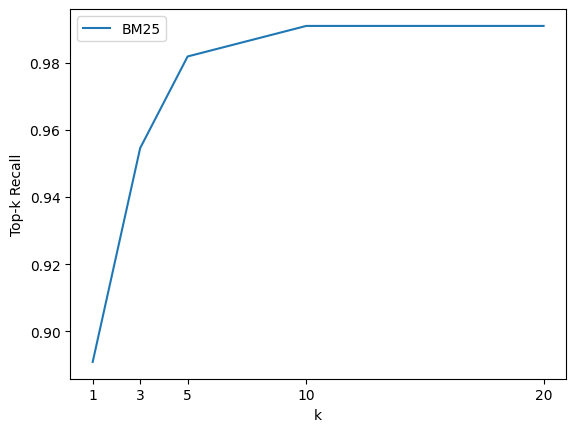

In [44]:
def plot_retriever_eval(dfs, retriever_names):
    fig, ax = plt.subplots()
    for df, retriever_name in zip(dfs, retriever_names):
        df.plot(y="recall", ax=ax, label=retriever_name)
    plt.xticks(df.index)
    plt.ylabel("Top-k Recall")
    plt.xlabel("k")
    plt.show()

plot_retriever_eval([bm25_topk_df], ["BM25"])


#### DPR

##### NQ 말뭉치에서 미세 튜닝한 인코더 사용

In [45]:
from haystack.nodes import DensePassageRetriever

dpr_retriever = DensePassageRetriever(document_store=document_store,
    query_embedding_model="facebook/dpr-question_encoder-single-nq-base",
    passage_embedding_model="facebook/dpr-ctx_encoder-single-nq-base",
    embed_title=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/493 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

##### 인덱스된 문서를 모두 순회하면서 인코더를 적용해 임베딩 표현 업데이트

In [46]:
document_store.update_embeddings(retriever=dpr_retriever)

Create embeddings: 100%|██████████| 1616/1616 [00:24<00:00, 68.21 Docs/s]
Updating embeddings: 10000 Docs [00:38, 256.49 Docs/s]


##### 밀집 리트리버를 평가, top-k 재현율을 비교

/usr/local/lib/python3.12/dist-packages/haystack/schema.py:1464: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  documents["matched_label_idxs"] = documents.apply(find_matched_label_idxs, axis=1)
/usr/local/lib/python3.12/dist-packages/haystack/schema.py:1464: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  documents["matched_label_idxs"] = documents.apply(find_matched_label_idxs, axis=1)
/usr/local/lib/python3.12/dist-packages/haystack/schema.py:1464: SettingWithCopyWarning: 
A value is trying to be set on a c

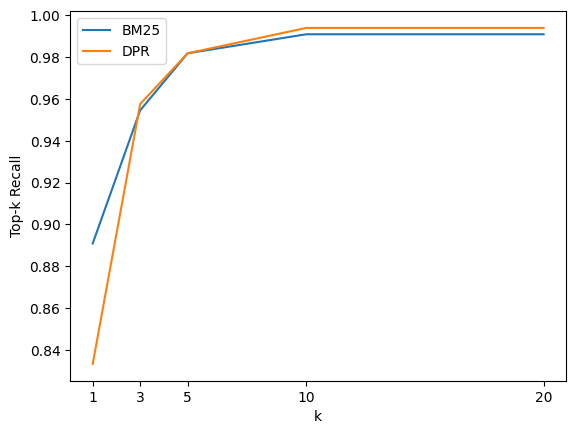

In [47]:
dpr_topk_df = evaluate_retriever(dpr_retriever)
plot_retriever_eval([bm25_topk_df, dpr_topk_df], ["BM25", "DPR"])

### 리더 평가하기

#### EM & F1-score

In [48]:
from haystack.modeling.evaluation.squad import compute_f1, compute_exact

pred = "about 6000 hours"
label = "6000 hours"
print(f"EM: {compute_exact(label, pred)}")
print(f"F1: {compute_f1(label, pred)}")

EM: 0
F1: 0.8


##### 예측한 답이 다를 경우

In [49]:
pred = "about 6000 dollars"
print(f"EM: {compute_exact(label, pred)}")
print(f"F1: {compute_f1(label, pred)}")

EM: 0
F1: 0.4


##### 리더를 평가하기 위한 노드 2개를 생성

In [50]:
from haystack.pipelines import Pipeline

def evaluate_reader(reader):
    score_keys = ['exact_match', 'f1']
    p = Pipeline()
    p.add_node(component=reader, name="Reader", inputs=["Query"])

    eval_result = p.eval(
        labels=labels_agg,
        documents= [[label.document for label in multilabel.labels] for multilabel in labels_agg],
        params={},
    )
    metrics = eval_result.calculate_metrics(simulated_top_k_reader=1)

    return {k:v for k,v in metrics["Reader"].items() if k in score_keys}

reader_eval = {}
reader_eval["Fine-tune on SQuAD"] = evaluate_reader(reader)


##### 점수 출력

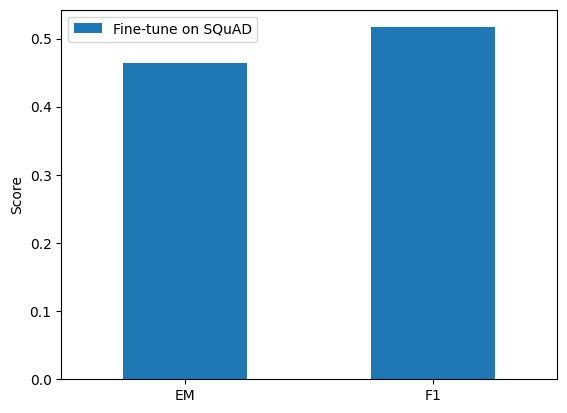

In [51]:
def plot_reader_eval(reader_eval):
    fig, ax = plt.subplots()
    df = pd.DataFrame.from_dict(reader_eval)
    df.plot(kind="bar", ylabel="Score", rot=0, ax=ax)
    ax.set_xticklabels(["EM", "F1"])
    plt.legend(loc='upper left')
    plt.show()

plot_reader_eval(reader_eval)

### 도메인 적응

##### paragraphs 배열을 만드는 함수

In [52]:
def create_paragraphs(df):
    paragraphs = []
    id2context = dict(zip(df["review_id"], df["context"]))
    for review_id, review in id2context.items():
        qas = []
        # 특정 문맥으로 전체 질문-답 쌍을 필터링
        review_df = df.query(f"review_id == '{review_id}'")
        id2question = dict(zip(review_df["id"], review_df["question"]))
        # qas 배열을 생성
        for qid, question in id2question.items():
            # 하나의 질문 ID에 대해 필터링
            question_df = df.query(f"id == '{qid}'").to_dict(orient="list")
            ans_start_idxs = question_df["answers.answer_start"][0].tolist()
            ans_text = question_df["answers.text"][0].tolist()
            # 답변 가능한 질문을 추가
            if len(ans_start_idxs):
                answers = [
                    {"text": text, "answer_start": answer_start}
                    for text, answer_start in zip(ans_text, ans_start_idxs)]
                is_impossible = False
            else:
                answers = []
                is_impossible = True
            # 질문-답 쌍을 qas에 추가
            qas.append({"question": question, "id": qid,
                        "is_impossible": is_impossible, "answers": answers})
        # 문맥과 질문-답 쌍을 paragraphs에 추가
        paragraphs.append({"qas": qas, "context": review})
    return paragraphs

##### 하나의 제품 ID에 연관된 데이터프레임의 열을 전달해 SQuAD 포맷 생성

In [53]:
product = dfs["train"].query("title == 'B00001P4ZH'")
create_paragraphs(product)

[{'qas': [{'question': 'How is the bass?',
    'id': '2543d296da9766d8d17d040ecc781699',
    'is_impossible': True,
    'answers': []}],
  'context': 'I have had Koss headphones in the past, Pro 4AA and QZ-99.  The Koss Portapro is portable AND has great bass response.  The work great with my Android phone and can be "rolled up" to be carried in my motorcycle jacket or computer bag without getting crunched.  They are very light and do not feel heavy or bear down on your ears even after listening to music with them on all day.  The sound is night and day better than any ear-bud could be and are almost as good as the Pro 4AA.  They are "open air" headphones so you cannot match the bass to the sealed types, but it comes close. For $32, you cannot go wrong.'},
 {'qas': [{'question': 'Is this music song have a goo bass?',
    'id': 'd476830bf9282e2b9033e2bb44bbb995',
    'is_impossible': False,
    'answers': [{'text': 'Bass is weak as expected', 'answer_start': 1302},
     {'text': 'Bass i

##### 각 분할의 데이터프레임에 있는 모든 제품 ID에 적용

In [54]:
import json

def convert_to_squad(dfs):
    for split, df in dfs.items():
        subjqa_data = {}
        # 각 제품 ID에 대해 `paragraphs`를 생성
        groups = (df.groupby("title").apply(create_paragraphs)
            .to_frame(name="paragraphs").reset_index())
        subjqa_data["data"] = groups.to_dict(orient="records")
        # 결과를 디스크에 저장
        with open(f"electronics-{split}.json", "w+", encoding="utf-8") as f:
            json.dump(subjqa_data, f)

convert_to_squad(dfs)

/tmp/ipykernel_10050/621479737.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  groups = (df.groupby("title").apply(create_paragraphs)
/tmp/ipykernel_10050/621479737.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  groups = (df.groupby("title").apply(create_paragraphs)
/tmp/ipykernel_10050/621479737.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is dep

##### 리더를 미세 튜닝

In [55]:
train_filename = "electronics-train.json"
dev_filename = "electronics-validation.json"

reader.train(data_dir=".", use_gpu=True, n_epochs=1, batch_size=16,
             train_filename=train_filename, dev_filename=dev_filename)

Preprocessing dataset:   0%|          | 0/3 [00:00<?, ? Dicts/s]WARNING:haystack.modeling.data_handler.processor:Answer 'These earbuds are nothing special. Their best attribute is that they are cheap. The sound from them is nothing special. In comparison to my standard white IPod buds these seem to emphasize the higher frequencies. There seems to be nothing happening in the bass range with these. I don't think they are efficient enough to have much bass at all. To be fair, my IPod buds overly emphasize bass so they are not that accurate either. I also compared these to a pricy Sennheiser set that I've owned for a couple of years and let's just say there is a reason why the Sennheisers cost more.Surely these Panasonic buds are very nice to use if you think they might get damaged somehow in use as it will not break your heart to have to replace them. These might be especially useful if you only listen to talk radio or have high frequency hearing loss. If you really like to listen to the 

##### 미세 튜닝된 리더의 테스트셋 성능을 기준 모델과 비교

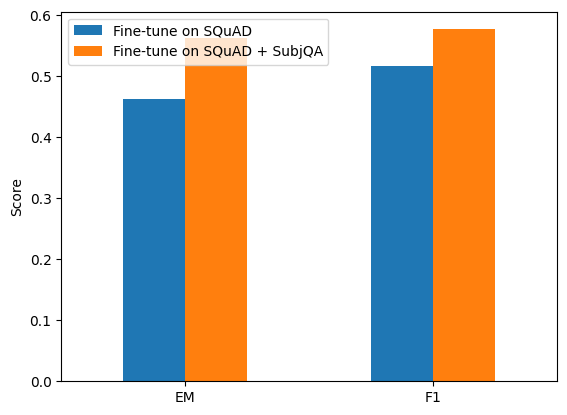

In [56]:
reader_eval["Fine-tune on SQuAD + SubjQA"] = evaluate_reader(reader)
plot_reader_eval(reader_eval)

##### 공정한 비교를 위해 SQuAD에서 기준 모델을 미세 튜닝할 때 사용한 언어 모델을 그대로 사용

In [57]:
minilm_ckpt = "microsoft/MiniLM-L12-H384-uncased"
minilm_reader = FARMReader(model_name_or_path=minilm_ckpt, progress_bar=False,
                           max_seq_len=max_seq_length, doc_stride=doc_stride,
                           return_no_answer=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/133M [00:00<?, ?B/s]

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at microsoft/MiniLM-L12-H384-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

##### 한 에폭동안 미세 튜닝

In [58]:
minilm_reader.train(data_dir=".", use_gpu=True, n_epochs=1, batch_size=16,
             train_filename=train_filename, dev_filename=dev_filename)

Preprocessing dataset:   0%|          | 0/3 [00:00<?, ? Dicts/s]WARNING:haystack.modeling.data_handler.processor:Answer 'These earbuds are nothing special. Their best attribute is that they are cheap. The sound from them is nothing special. In comparison to my standard white IPod buds these seem to emphasize the higher frequencies. There seems to be nothing happening in the bass range with these. I don't think they are efficient enough to have much bass at all. To be fair, my IPod buds overly emphasize bass so they are not that accurate either. I also compared these to a pricy Sennheiser set that I've owned for a couple of years and let's just say there is a reason why the Sennheisers cost more.Surely these Panasonic buds are very nice to use if you think they might get damaged somehow in use as it will not break your heart to have to replace them. These might be especially useful if you only listen to talk radio or have high frequency hearing loss. If you really like to listen to the 

##### 테스트셋에서 평가해 이전 결과와 비교

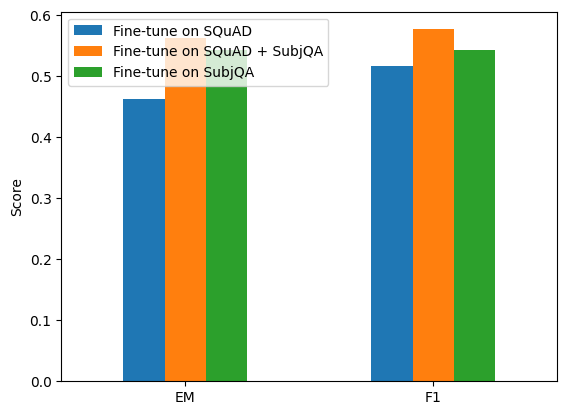

In [59]:
reader_eval["Fine-tune on SubjQA"] = evaluate_reader(minilm_reader)
plot_reader_eval(reader_eval)

### 전체 QA 파이프라인 평가하기

##### 리더의 성능에 미치는 영향을 평가

In [60]:
from haystack.pipelines import ExtractiveQAPipeline
pipe = ExtractiveQAPipeline(retriever=es_retriever, reader=reader)

# 평가하기!
eval_result = pipe.eval(
    labels=labels_agg,
    params={},
)
metrics = eval_result.calculate_metrics(simulated_top_k_reader=1)
# 리더에서 지표를 추출
reader_eval["QA Pipeline (top-1)"] = {
    k:v for k,v in metrics["Reader"].items()
    if k in ["exact_match", "f1"]}

##### 리더와 전체 QA 파이프라인의 EM과 F1-score 비교

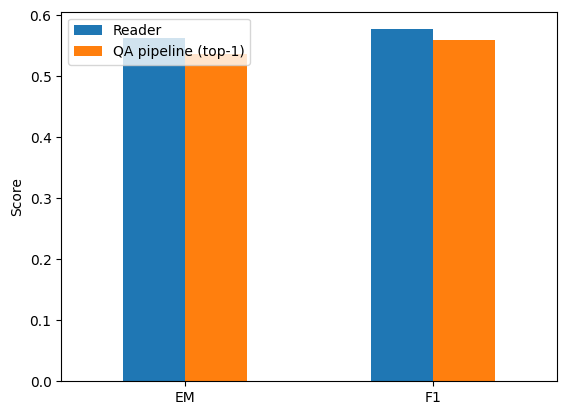

In [61]:
plot_reader_eval({"Reader": reader_eval["Fine-tune on SQuAD + SubjQA"],
                  "QA pipeline (top-1)": reader_eval["QA Pipeline (top-1)"]})

## 추출적 QA를 넘어서

##### RAG

In [ ]:
from haystack.generator.transformers import RAGenerator

generator = RAGenerator(
    model_name_or_path="facebook/rag-token-nq",
    embed_title=False, num_beans=5)

##### 리트리버와 제너레이터 연결

In [ ]:
from haystack.pipelines import GenerativeQAPipeline

pipe = GenerativeQAPipeline(generator=generator, retriever=dpr_retriever)

##### 쿼리를 받고 최상의 답을 출력하는 함수

In [ ]:
def generate_answers(query, top_k_generator=3):
    preds = pipe.run(query=query,
                     params={"Retriever": {"top_k":5,
                                  "filters":{"item_id": ["B0074BW614"]}},
                             "Generator": {"top_k": top_k_generator}})
    print(f"질문: {preds['query']} \n")
    for idx in range(top_k_generator):
        print(f"답변 {idx + 1}: {preds['answers'][idx].answer}")

##### 테스트

In [ ]:
generate_answers(query)

##### 더 사실에 관한 질문

In [ ]:
generate_answers("What is the main drawback?")